In [11]:
import math
import random
from copy import deepcopy
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import TensorDataset, DataLoader
from IPython.display import display

In [12]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


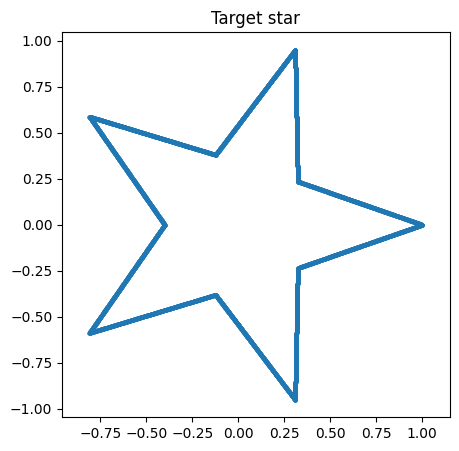

In [13]:
def generate_star(
    n_spikes: int = 5,
    inner_radius: float = 0.4,
    outer_radius: float = 1.0,
    n_samples: int = 5000,
    center: tuple[float, float] = (0.0, 0.0),
) -> np.ndarray:
    angle_step = np.pi / n_spikes
    vertices = []

    for i in range(2 * n_spikes):
        angle = i * angle_step
        radius = outer_radius if i % 2 == 0 else inner_radius
        x = radius * np.cos(angle) + center[0]
        y = radius * np.sin(angle) + center[1]
        vertices.append([x, y])

    vertices.append(vertices[0])
    vertices = np.array(vertices, dtype=np.float32)

    sampled_points = []
    points_per_edge = n_samples // (len(vertices) - 1)

    for i in range(len(vertices) - 1):
        start_point = vertices[i]
        end_point = vertices[i + 1]

        for t in np.linspace(0.0, 1.0, points_per_edge):
            point = (1.0 - t) * start_point + t * end_point
            sampled_points.append(point)

    return np.array(sampled_points, dtype=np.float32)


star = generate_star(n_samples=5000)

plt.figure(figsize=(5, 5))
plt.scatter(star[:, 0], star[:, 1], s=4)
plt.axis("equal")
plt.title("Target star")
plt.show()

In [14]:
@dataclass
class Config:
    lr: float = 1e-3
    epochs: int = 400
    batch_size: int = 512
    hidden_dim: int = 128
    num_timesteps: int = 500
    data_samples: int = 5000

    beta_min: float = 0.1
    beta_max: float = 20.0
    cosine_s: float = 0.008

    t_eps: float = 1e-3
    schedule: str = "linear"
    loss_weighting: str = "none"
    time_sampling_power: float = 2.0
    weight_clip: float = 20.0

    ema_decay: float = 0.999
    pc_corrector_steps: int = 2
    pc_snr: float = 0.15

    seed: int = 42

In [15]:
class ScoreModel(nn.Module):
    def __init__(self, config: Config) -> None:
        super().__init__()

        self.time_embed = nn.Sequential(
            nn.Linear(1, config.hidden_dim),
            nn.SiLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim),
            nn.SiLU(),
        )

        self.net = nn.Sequential(
            nn.Linear(2 + config.hidden_dim, config.hidden_dim),
            nn.SiLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim),
            nn.SiLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim),
            nn.SiLU(),
            nn.Linear(config.hidden_dim, 2),
        )

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        t_embed = self.time_embed(t)
        x_input = torch.cat([x, t_embed], dim=1)
        return self.net(x_input)


class EMA:
    def __init__(self, model: nn.Module, decay: float) -> None:
        self.decay = decay
        self.shadow = {
            name: param.detach().clone()
            for name, param in model.named_parameters()
            if param.requires_grad
        }

    @torch.no_grad()
    def update(self, model: nn.Module) -> None:
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.shadow[name].mul_(self.decay).add_(param.detach(), alpha=1.0 - self.decay)

    @torch.no_grad()
    def copy_to(self, model: nn.Module) -> None:
        for name, param in model.named_parameters():
            if param.requires_grad:
                param.data.copy_(self.shadow[name].data)

In [16]:
def prepare_data(config: Config):
    raw_data = torch.tensor(generate_star(n_samples=config.data_samples), dtype=torch.float32)
    data_mean = raw_data.mean(dim=0, keepdim=True)
    data_std = raw_data.std(dim=0, keepdim=True).clamp_min(1e-6)
    normalized_data = (raw_data - data_mean) / data_std

    dataset = TensorDataset(normalized_data)
    dataloader = DataLoader(dataset, batch_size=config.batch_size, shuffle=True)
    return raw_data, normalized_data, data_mean, data_std, dataloader


def alpha_bar_t(t: torch.Tensor, config: Config) -> torch.Tensor:
    if config.schedule == "linear":
        integral_beta = config.beta_min * t + 0.5 * (config.beta_max - config.beta_min) * t ** 2
        return torch.exp(-integral_beta).clamp(1e-12, 1.0)

    if config.schedule == "cosine":
        s = config.cosine_s
        angle_t = (t + s) / (1.0 + s) * math.pi / 2.0
        angle_0 = s / (1.0 + s) * math.pi / 2.0
        alpha_bar = (torch.cos(angle_t) ** 2) / (math.cos(angle_0) ** 2)
        return alpha_bar.clamp(1e-12, 1.0)

    raise ValueError(f"Unknown schedule: {config.schedule}")


def alpha_t(t: torch.Tensor, config: Config) -> torch.Tensor:
    return torch.sqrt(alpha_bar_t(t, config))


def std_t(t: torch.Tensor, config: Config) -> torch.Tensor:
    return torch.sqrt((1.0 - alpha_bar_t(t, config)).clamp_min(1e-12))


def beta_t(t: torch.Tensor, config: Config) -> torch.Tensor:
    if config.schedule == "linear":
        beta = config.beta_min + (config.beta_max - config.beta_min) * t
        return beta.clamp_min(1e-8)

    if config.schedule == "cosine":
        s = config.cosine_s
        angle = (t + s) / (1.0 + s) * math.pi / 2.0
        beta = math.pi * torch.tan(angle) / (1.0 + s)
        return beta.clamp(1e-8, config.beta_max)

    raise ValueError(f"Unknown schedule: {config.schedule}")


def loss_weight_t(t: torch.Tensor, config: Config) -> torch.Tensor:
    sigma2 = std_t(t, config) ** 2
    snr = alpha_bar_t(t, config) / (1.0 - alpha_bar_t(t, config)).clamp_min(1e-12)

    if config.loss_weighting == "none":
        return torch.ones_like(t)

    if config.loss_weighting == "sigma2":
        return sigma2

    if config.loss_weighting == "sqrt_snr":
        return torch.sqrt(torch.clamp(snr, max=config.weight_clip))

    if config.loss_weighting == "snr":
        return torch.clamp(snr, max=config.weight_clip)

    raise ValueError(f"Unknown loss weighting: {config.loss_weighting}")

In [17]:
class VPSDETrainer:
    def __init__(self, config: Config) -> None:
        set_seed(config.seed)
        self.config = config
        self.device = device

        self.raw_data, self.data, self.data_mean, self.data_std, self.dataloader = prepare_data(config)

        self.model = ScoreModel(config).to(self.device)
        self.ema_model = ScoreModel(config).to(self.device)
        self.ema_model.load_state_dict(self.model.state_dict())

        self.optimizer = optim.Adam(self.model.parameters(), lr=config.lr)
        self.ema = EMA(self.model, config.ema_decay)
        self.loss_history = []

    def sample_t(self, batch_size: int) -> torch.Tensor:
        u = torch.rand(batch_size, 1, device=self.device)
        t = self.config.t_eps + (1.0 - 2.0 * self.config.t_eps) * (u ** self.config.time_sampling_power)
        return t

    def train_epoch(self) -> float:
        self.model.train()
        total_loss = 0.0
        total_count = 0

        for (batch,) in self.dataloader:
            batch = batch.to(self.device)

            t = self.sample_t(batch.shape[0])

            alpha = alpha_t(t, self.config)
            sigma = std_t(t, self.config)

            noise = torch.randn_like(batch)
            x_t = alpha * batch + sigma * noise

            pred_noise = self.model(x_t, t)
            weights = loss_weight_t(t, self.config)

            per_item_loss = F.mse_loss(pred_noise, noise, reduction="none").mean(dim=1, keepdim=True)
            loss = (weights * per_item_loss).mean()

            self.optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.optimizer.step()
            self.ema.update(self.model)

            total_loss += loss.item() * batch.shape[0]
            total_count += batch.shape[0]

        return total_loss / total_count

    def run(self, verbose: bool = True, log_every: int = 100):
        for epoch in range(self.config.epochs):
            loss = self.train_epoch()
            self.loss_history.append(loss)

            if verbose and (epoch == 0 or (epoch + 1) % log_every == 0 or epoch + 1 == self.config.epochs):
                print(
                    f"epoch={epoch + 1:04d} | "
                    f"loss={loss:.6f} | "
                    f"schedule={self.config.schedule} | "
                    f"weighting={self.config.loss_weighting}"
                )

        self.ema.copy_to(self.ema_model)
        return self.loss_history

In [18]:
@torch.no_grad()
def sample_vp_sde(
    model: nn.Module,
    config: Config,
    data_mean: torch.Tensor,
    data_std: torch.Tensor,
    num_samples: int = 1500,
) -> np.ndarray:
    model.eval()
    model_device = next(model.parameters()).device

    x = torch.randn(num_samples, 2, device=model_device)

    dt = (1.0 - 2.0 * config.t_eps) / config.num_timesteps

    for i in range(config.num_timesteps):
        t_value = 1.0 - config.t_eps - i * dt
        t_value = max(t_value, config.t_eps)

        t_tensor = torch.full((num_samples, 1), t_value, device=model_device)

        sigma = std_t(t_tensor, config).clamp_min(1e-5)

        for _ in range(config.pc_corrector_steps):
            pred_noise = model(x, t_tensor)
            score = -pred_noise / sigma

            noise = torch.randn_like(x)
            grad_norm = torch.norm(score, dim=1).mean()
            noise_norm = torch.norm(noise, dim=1).mean()
            step_size = 2.0 * (config.pc_snr * noise_norm / (grad_norm + 1e-8)) ** 2

            x = x + step_size * score + torch.sqrt(2.0 * step_size) * noise

        pred_noise = model(x, t_tensor)
        score = -pred_noise / sigma
        beta = beta_t(t_tensor, config)

        x = x + (0.5 * beta * x + beta * score) * dt + torch.sqrt(beta * dt) * torch.randn_like(x)

    t_tensor = torch.full((num_samples, 1), config.t_eps, device=model_device)
    alpha_last = alpha_t(t_tensor, config).clamp_min(1e-5)
    sigma_last = std_t(t_tensor, config)
    pred_noise = model(x, t_tensor)
    x = (x - sigma_last * pred_noise) / alpha_last

    x = x * data_std.to(model_device) + data_mean.to(model_device)
    return x.cpu().numpy()


def chamfer_distance(x: np.ndarray, y: np.ndarray) -> float:
    x_tensor = torch.tensor(x, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32)
    distances = torch.cdist(x_tensor, y_tensor).pow(2)
    return (
        distances.min(dim=1).values.mean() +
        distances.min(dim=0).values.mean()
    ).item()


def random_subset(points: np.ndarray, size: int, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    size = min(size, len(points))
    indices = rng.choice(len(points), size=size, replace=False)
    return points[indices]


def run_experiment(
    config: Config,
    num_samples: int = 1500,
    metric_samples: int = 1000,
    verbose: bool = False,
):
    trainer = VPSDETrainer(config)
    trainer.run(verbose=verbose, log_every=100)

    samples = sample_vp_sde(
        trainer.ema_model,
        config,
        trainer.data_mean,
        trainer.data_std,
        num_samples=num_samples,
    )

    reference = trainer.raw_data.numpy()

    metric_generated = random_subset(samples, metric_samples, config.seed)
    metric_reference = random_subset(reference, metric_samples, config.seed + 1)
    chamfer = chamfer_distance(metric_generated, metric_reference)

    return {
        "config": deepcopy(config),
        "loss_history": trainer.loss_history,
        "samples": samples,
        "reference": reference,
        "final_loss": trainer.loss_history[-1],
        "chamfer": chamfer,
        "model": trainer.ema_model,
        "data_mean": trainer.data_mean,
        "data_std": trainer.data_std,
    }

In [19]:
def plot_loss_curves(results: dict, title: str) -> None:
    plt.figure(figsize=(8, 4))
    for name, result in results.items():
        plt.plot(result["loss_history"], label=name)
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()


def plot_sample_grid(results: dict, title: str, ncols: int = 2, point_size: int = 4) -> None:
    names = list(results.keys())
    nrows = math.ceil(len(names) / ncols)

    plt.figure(figsize=(5 * ncols, 5 * nrows))
    for i, name in enumerate(names, start=1):
        samples = results[name]["samples"]
        plt.subplot(nrows, ncols, i)
        plt.scatter(samples[:, 0], samples[:, 1], s=point_size)
        plt.axis("equal")
        plt.title(name)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def experiment_table(results: dict, key_name: str) -> pd.DataFrame:
    rows = []
    for name, result in results.items():
        rows.append(
            {
                key_name: name,
                "final_loss": result["final_loss"],
                "chamfer": result["chamfer"],
            }
        )
    return pd.DataFrame(rows).sort_values("chamfer").reset_index(drop=True)

,loss_weighting,final_loss,chamfer
0,snr,5.522380,0.012520
1,sqrt_snr,1.408271,0.013362
2,none,0.440188,0.036389
3,sigma2,0.083724,0.042025


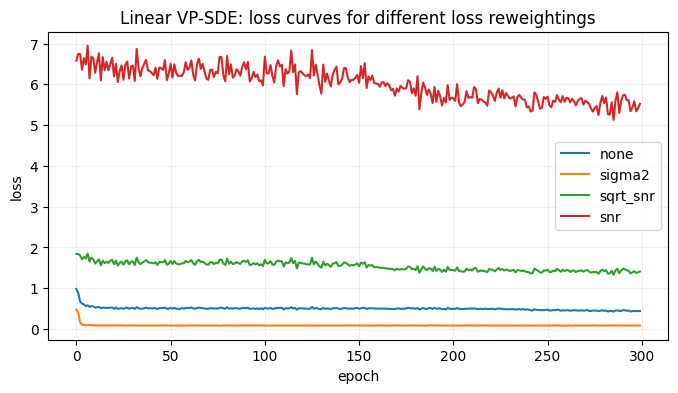

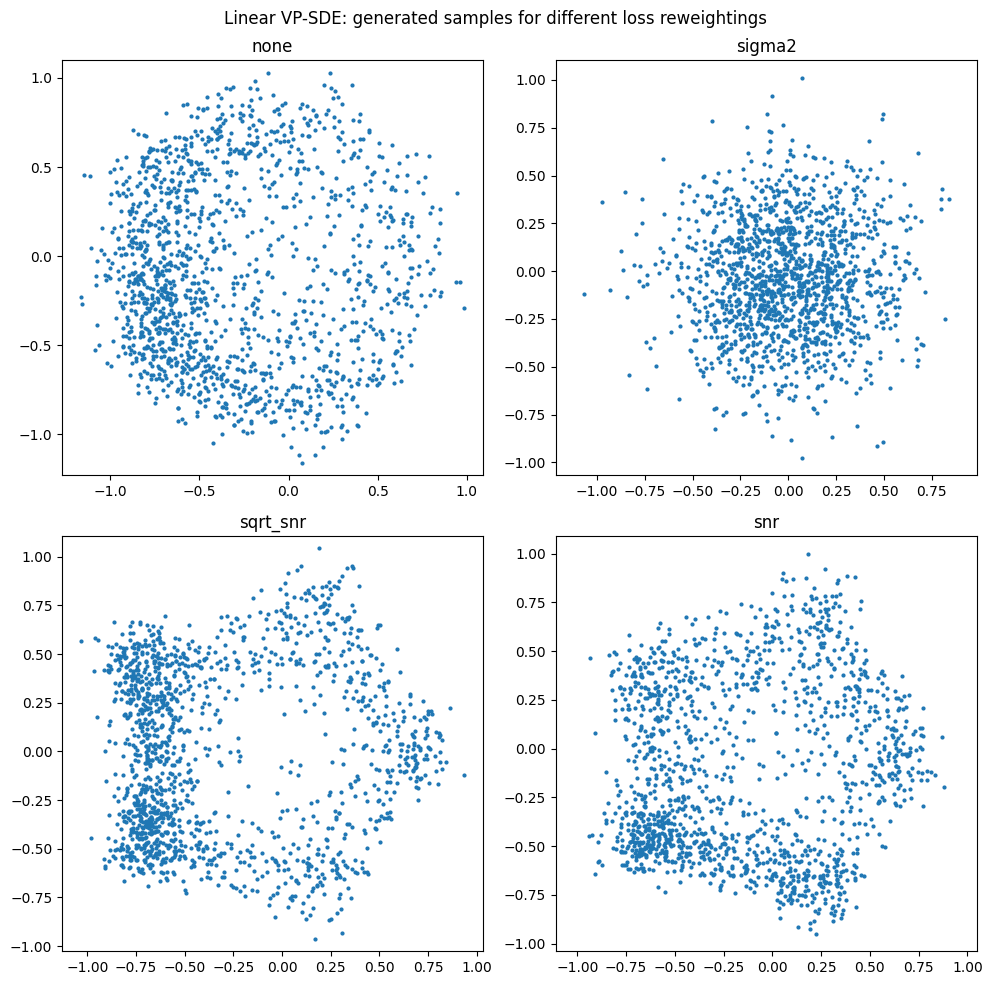

Best weighting by chamfer: snr


In [20]:
weightings = ["none", "sigma2", "sqrt_snr", "snr"]

weight_results = {}

for weighting in weightings:
    cfg = Config()
    cfg.schedule = "linear"
    cfg.loss_weighting = weighting
    cfg.epochs = 300
    cfg.num_timesteps = 500
    cfg.hidden_dim = 128
    cfg.time_sampling_power = 2.0
    cfg.pc_corrector_steps = 2
    cfg.pc_snr = 0.15

    weight_results[weighting] = run_experiment(
        cfg,
        num_samples=1500,
        metric_samples=1000,
        verbose=False,
    )

weight_df = experiment_table(weight_results, "loss_weighting")
display(weight_df)

plot_loss_curves(weight_results, "Linear VP-SDE: loss curves for different loss reweightings")
plot_sample_grid(weight_results, "Linear VP-SDE: generated samples for different loss reweightings", ncols=2)

best_weighting = weight_df.loc[0, "loss_weighting"]
print(f"Best weighting by chamfer: {best_weighting}")

,schedule,final_loss,chamfer
0,linear,5.522380,0.012520
1,cosine,7.433958,0.014971


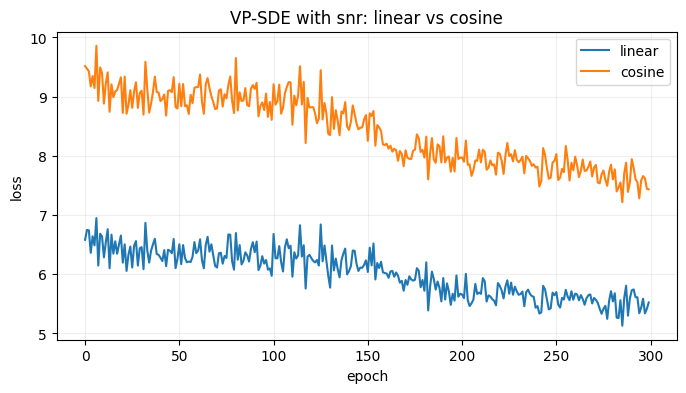

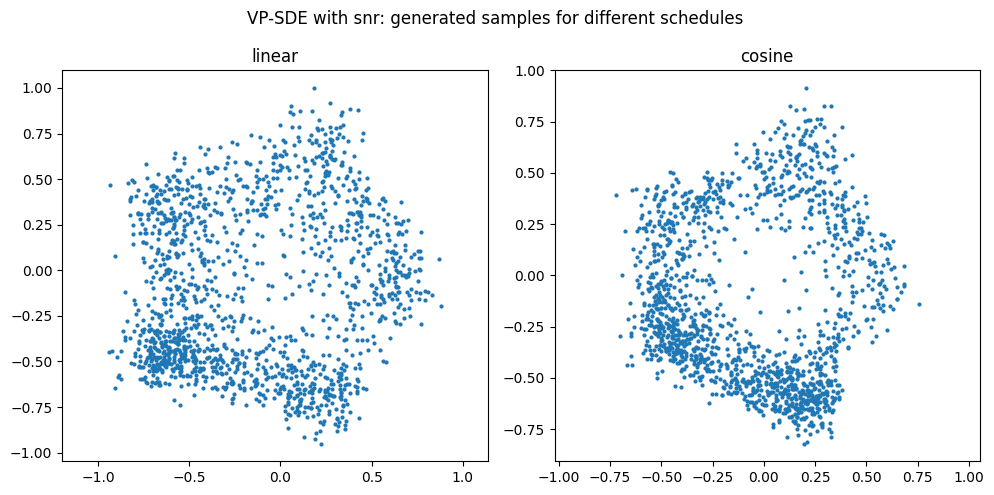

Best schedule by chamfer: linear


In [21]:
schedules = ["linear", "cosine"]

schedule_results = {}

for schedule in schedules:
    cfg = Config()
    cfg.schedule = schedule
    cfg.loss_weighting = best_weighting
    cfg.epochs = 300
    cfg.num_timesteps = 500
    cfg.hidden_dim = 128
    cfg.time_sampling_power = 2.0
    cfg.pc_corrector_steps = 2
    cfg.pc_snr = 0.15

    schedule_results[schedule] = run_experiment(
        cfg,
        num_samples=1500,
        metric_samples=1000,
        verbose=False,
    )

schedule_df = experiment_table(schedule_results, "schedule")
display(schedule_df)

plot_loss_curves(schedule_results, f"VP-SDE with {best_weighting}: linear vs cosine")
plot_sample_grid(schedule_results, f"VP-SDE with {best_weighting}: generated samples for different schedules", ncols=2)

best_schedule = schedule_df.loc[0, "schedule"]
print(f"Best schedule by chamfer: {best_schedule}")

epoch=0001 | loss=6.581149 | schedule=linear | weighting=snr
epoch=0100 | loss=5.972967 | schedule=linear | weighting=snr
epoch=0200 | loss=5.670346 | schedule=linear | weighting=snr
epoch=0300 | loss=5.522380 | schedule=linear | weighting=snr
epoch=0400 | loss=5.131092 | schedule=linear | weighting=snr
epoch=0500 | loss=4.839011 | schedule=linear | weighting=snr
epoch=0600 | loss=4.452229 | schedule=linear | weighting=snr
epoch=0700 | loss=4.782928 | schedule=linear | weighting=snr
epoch=0800 | loss=4.647461 | schedule=linear | weighting=snr
epoch=0900 | loss=4.497458 | schedule=linear | weighting=snr
epoch=1000 | loss=4.333697 | schedule=linear | weighting=snr
epoch=1100 | loss=4.617939 | schedule=linear | weighting=snr
epoch=1200 | loss=4.261231 | schedule=linear | weighting=snr
epoch=1300 | loss=4.285812 | schedule=linear | weighting=snr
epoch=1400 | loss=4.451052 | schedule=linear | weighting=snr
epoch=1500 | loss=4.206615 | schedule=linear | weighting=snr


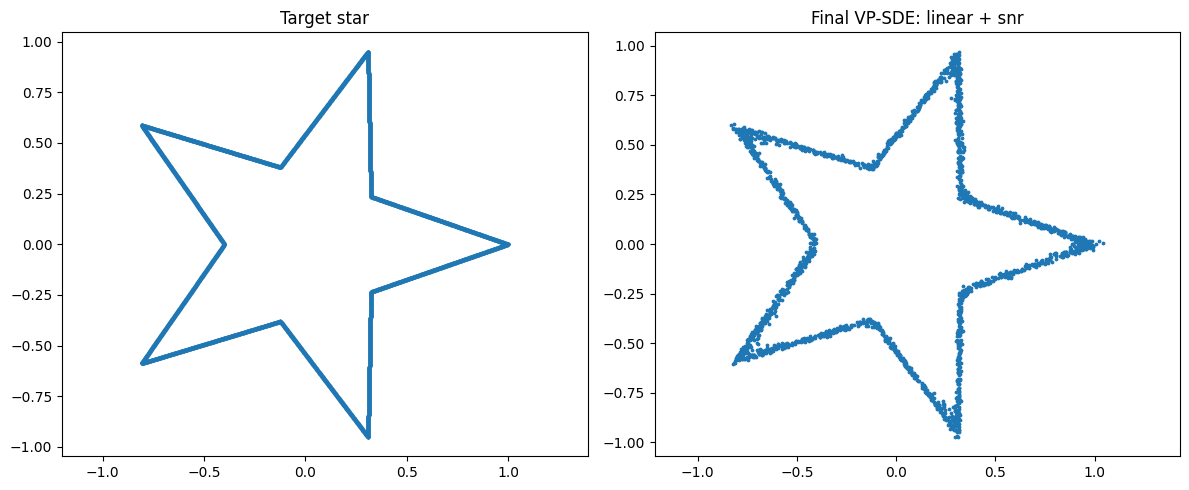

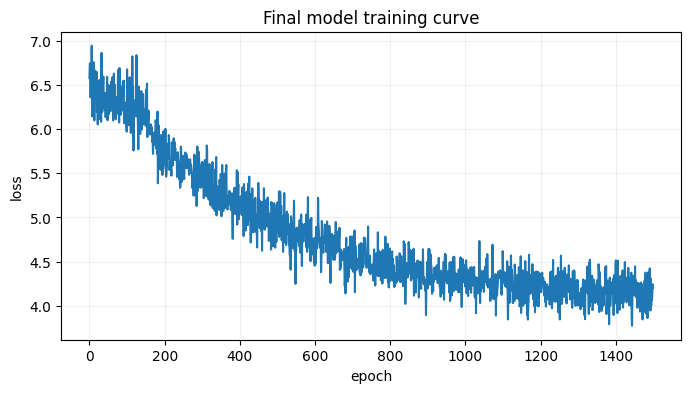

,schedule,loss_weighting,final_loss,chamfer,epochs,num_timesteps
0,linear,snr,4.206615,0.000143,1500,500


In [23]:
final_config = Config()
final_config.schedule = best_schedule
final_config.loss_weighting = best_weighting
final_config.epochs = 1500
final_config.num_timesteps = 500
final_config.hidden_dim = 128
final_config.time_sampling_power = 2.0
final_config.pc_corrector_steps = 3
final_config.pc_snr = 0.2

final_result = run_experiment(
    final_config,
    num_samples=2500,
    metric_samples=1200,
    verbose=True,
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(star[:, 0], star[:, 1], s=3)
plt.axis("equal")
plt.title("Target star")

plt.subplot(1, 2, 2)
plt.scatter(final_result["samples"][:, 0], final_result["samples"][:, 1], s=3)
plt.axis("equal")
plt.title(f"Final VP-SDE: {best_schedule} + {best_weighting}")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(final_result["loss_history"])
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Final model training curve")
plt.grid(alpha=0.2)
plt.show()

final_metrics = pd.DataFrame(
    [
        {
            "schedule": best_schedule,
            "loss_weighting": best_weighting,
            "final_loss": final_result["final_loss"],
            "chamfer": final_result["chamfer"],
            "epochs": final_config.epochs,
            "num_timesteps": final_config.num_timesteps,
        }
    ]
)
display(final_metrics)

## Выводы

Реализована VP-SDE диффузия и выполнена генерация на задаче со звездой.

Все рассмотренные конфигурации восстанавливают форму звезды, но качество различается.

Основные наблюдения:
- snr-weighting даёт наиболее чёткий и устойчивый контур звезды;
- uniform weighting даёт рабочий, но менее выразительный результат;
- sigma2 чаще приводит к переусреднению и потере формы;
- sqrt_snr работает лучше uniform, но уступает полному snr;
- в данном запуске linear schedule показал лучший результат, чем cosine.

Итог: лучшая конфигурация в этом эксперименте — VP-SDE + linear schedule + snr-weighting.